In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from datasets import load_dataset

In [2]:
repo_id = 'kuleshov-group/cross-species-single-nucleotide-annotation'

In [3]:
data = load_dataset(repo_id, data_files={'valid': 'Evolutionary_constraint/valid.tsv'})
df = data['valid'].to_pandas()
REF = df['sequences'].str[255]

In [4]:
REF.head()

0    T
1    A
2    C
3    T
4    G
Name: sequences, dtype: object

In [5]:
logits = pd.read_csv('/workdir/jz963/utils/plantcad2/results/evolutionary_constraint/mutation_scores_evo2.tsv', sep='\t')
logits.columns = ['A', 'C', 'G', 'T']


In [6]:
logits.head()

,A,C,G,T
0,-1.100241,-1.094041,-1.098336,-1.094071
1,-0.969388,-0.969668,-0.970002,-0.969342
2,-1.108567,-1.106619,-1.109202,-1.108304
3,-1.032046,-1.032124,-1.032074,-1.032082
4,-1.067483,-1.071633,-1.067068,-1.071258


In [7]:
scores = df.apply(
   lambda row: logits.loc[row.name, REF.loc[row.name]] / logits.loc[row.name].sum() if REF.loc[row.name] in "ATCG" else 0,
   axis=1
)

In [8]:
y_true = df['label']


In [12]:
df['label'].value_counts()

label
1    19030
0    19030
Name: count, dtype: int64

In [9]:
y_scores = scores
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

In [10]:
roc_auc

0.31059414995655005

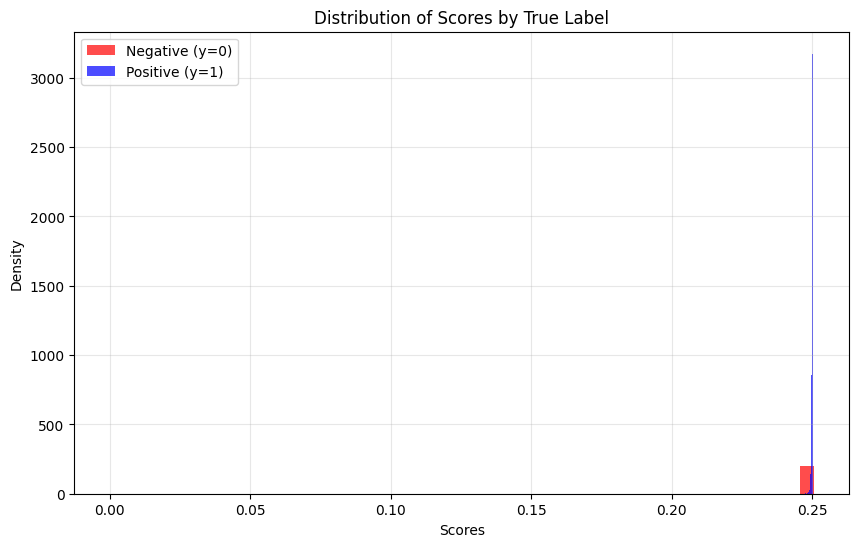

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate positive and negative scores based on y_true labels
positive_scores = scores[y_true == 1]
negative_scores = scores[y_true == 0]

# Create the plot
plt.figure(figsize=(10, 6))

# Plot histograms
plt.hist(negative_scores, bins=50, alpha=0.7, label='Negative (y=0)', color='red', density=True)
plt.hist(positive_scores, bins=50, alpha=0.7, label='Positive (y=1)', color='blue', density=True)

plt.xlabel('Scores')
plt.ylabel('Density')
plt.title('Distribution of Scores by True Label')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()